In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [5]:
sim = bacco.utils.load_MTNG()

2024-04-09 14:30:26,154 bacco.sims : Initialising simulation Default
2024-04-09 14:30:26,155 bacco.sims : try /scratch/cosmosims/TNG_Family/MTNG/groups_252/fof_subhalo_tab_252
2024-04-09 14:30:26,197 bacco.sims : Loading /scratch/cosmosims/TNG_Family/MTNG/groups_252/fof_subhalo_tab_252
/lscratch/fgmaion/baccogit/bacco/simulation.py:1376: UserWarning: loadtxt: input contained no data: "/scratch/cosmosims/TNG_Family/MTNG//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-04-09 14:30:26,229 bacco.sims : Warning: Empty snaplist.txt
2024-04-09 14:30:26,230 bacco.sims : ...done in 0.0531 s


In [7]:
Nbins = 30

splitter = utils.split_halos(sim)
#dic_full = splitter.stellar_mf(mass_edges=[8, 15], nbins=Nbins)

### Define ranges of halo mass

In [83]:
mass_edges=np.array([[11,11.2],[11.2,11.4],[11.4,11.6],[11.6,11.8],[11.8,12],\
                     [12,12.2],[12.2,12.4],[12.4,12.6],[12.6,12.8],[12.8,13],\
                     [13,13.2],[13.2,13.4],[13.4,13.6],[13.6,13.8],[13.8,14],\
                     [14,14.2],[14.2,14.4],[14.4,14.6],[14.6,14.8],[14.8,15]])

# mass_edges=np.array([[13,13.2],[13.2,13.4],[13.8,14],\
#                      [14,14.2],[14.2,14.4],[14.8,15]])

### Get the subhalo selection

In [191]:
sel_total = splitter.subhalo_sel(mhalo_edges=np.array([[8,15]]), vmax_sel=False, Nhalos=None)

In [229]:
sels = ['14', '7', '2']

sel = {}
sel['14'] = splitter.subhalo_sel(mhalo_edges=mass_edges, vmax_sel=False, Nhalos=14)
sel['7'] = splitter.subhalo_sel(mhalo_edges=mass_edges, vmax_sel=False, Nhalos=7)
sel['2'] = splitter.subhalo_sel(mhalo_edges=mass_edges, vmax_sel=False, Nhalos=2)

### Compute bias for subhalos in each halo-mass bin

In [121]:
bias_total = splitter.bias_sm(sel_mask=sel_total['sel'], recompute=False)

In [234]:
bias = {}

bias['14'] = splitter.bias_sm(sel_mask=sel['14'], recompute=False)
bias['7']  = splitter.bias_sm(sel_mask=sel['7'], recompute=False)
bias['2']  = splitter.bias_sm(sel_mask=sel['2'], recompute=False)

In [235]:
D = 0.2
ms_edges = np.arange(9,13,D)
ms_centers = 0.5 * ( ms_edges[1:] + ms_edges[:-1] )

Text(0, 0.5, '$c_s$')

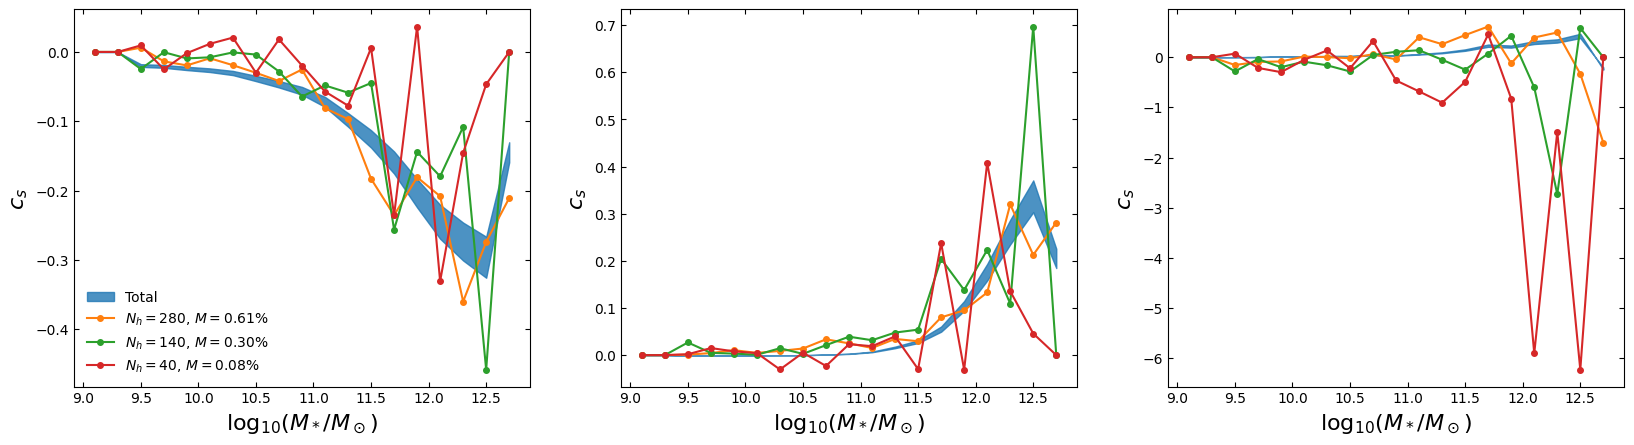

In [243]:
fig, ax = plt.subplots(1, 3, dpi=100, figsize=(20,5))
ax[0].fill_between(ms_centers, 0.9*bias_total['bias'][:,1], 1.1*bias_total['bias'][:,1], color='C0', alpha=0.8, label='Total')

ax[0].plot(ms_centers, bias['14']['bias'][:,1], ls='-', color='C1', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['14']['Nh'], 100*sel['14']['mh_tot']/sel_total['mh_tot']))
ax[0].plot(ms_centers, bias['7']['bias'][:,1], ls='-', color='C2', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['7']['Nh'], 100*sel['7']['mh_tot']/sel_total['mh_tot']))
ax[0].plot(ms_centers, bias['2']['bias'][:,1], ls='-', color='C3', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['2']['Nh'], 100*sel['2']['mh_tot']/sel_total['mh_tot']))

ax[0].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[0].set_ylabel('$c_s$', fontsize=16)

ax[0].legend(loc='lower left')

#############################

ax[1].fill_between(ms_centers, 0.9*bias_total['bias'][:,3], 1.1*bias_total['bias'][:,3], color='C0', alpha=0.8, label='Total')

ax[1].plot(ms_centers, bias['14']['bias'][:,3], ls='-', color='C1', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['14']['Nh'], 100*sel['14']['mh_tot']/sel_total['mh_tot']))
ax[1].plot(ms_centers, bias['7']['bias'][:,3], ls='-', color='C2', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['7']['Nh'], 100*sel['7']['mh_tot']/sel_total['mh_tot']))
ax[1].plot(ms_centers, bias['2']['bias'][:,3], ls='-', color='C3', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['2']['Nh'], 100*sel['2']['mh_tot']/sel_total['mh_tot']))

ax[1].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[1].set_ylabel('$c_s$', fontsize=16)

#############################

ax[2].fill_between(ms_centers, 0.9*bias_total['bias'][:,5], 1.1*bias_total['bias'][:,5], color='C0', alpha=0.8, label='Total')

ax[2].plot(ms_centers, bias['14']['bias'][:,5], ls='-', color='C1', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['14']['Nh'], 100*sel['14']['mh_tot']/sel_total['mh_tot']))
ax[2].plot(ms_centers, bias['7']['bias'][:,5], ls='-', color='C2', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['7']['Nh'], 100*sel['7']['mh_tot']/sel_total['mh_tot']))
ax[2].plot(ms_centers, bias['2']['bias'][:,5], ls='-', color='C3', marker='o', ms=4, label='$N_h=${:d}, $M={:.2f}\%$'.format(sel['2']['Nh'], 100*sel['2']['mh_tot']/sel_total['mh_tot']))

ax[2].set_xlabel('$\\log_{10}(M_*/M_\\odot)$', fontsize=16)
ax[2].set_ylabel('$c_s$', fontsize=16)

In [217]:
nbins=30
smf_total = splitter.stellar_mf(sel_mask=sel_total, nbins=nbins)

smf = {}
smf['14'] = splitter.stellar_mf(sel_mask=sel['14'], nbins=nbins)
smf['7'] = splitter.stellar_mf(sel_mask=sel['7'], nbins=nbins)
smf['2'] = splitter.stellar_mf(sel_mask=sel['2'], nbins=nbins)

In [152]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))
/tmp/ipykernel_87511/557292493.py:39: RuntimeWarning

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

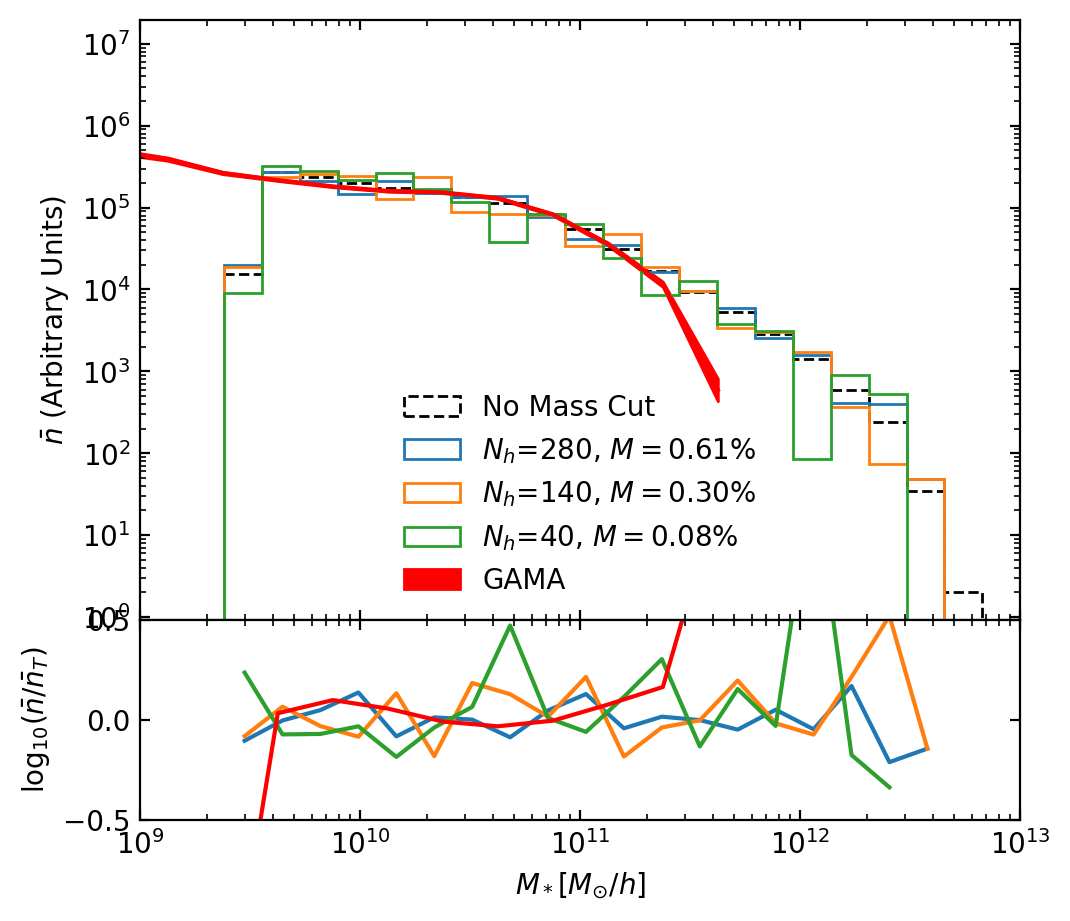

In [231]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

centers = 0.5*(smf_total['bins'][1:] + smf_total['bins'][:-1])
bins = smf['14']['bins']

ax1.hist(centers, bins=bins, weights=smf_total['smf'],\
         log=True, histtype='step', color='k', label='No Mass Cut', ls='--');

ax1.hist(centers, bins=bins, weights=smf['14']['smf'],\
         log=True, histtype='step', color='C0', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['14']['Nh'], 100*sel['14']['mh_tot']/sel_total['mh_tot']));

ax1.hist(centers, bins=bins, weights=smf['7']['smf'],\
         log=True, histtype='step', color='C1', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['7']['Nh'], 100*sel['7']['mh_tot']/sel_total['mh_tot']));

ax1.hist(centers, bins=bins, weights=smf['2']['smf'],\
         log=True, histtype='step', color='C2', label='$N_h$={:d}, $M={:.2f}\%$'.format(sel['2']['Nh'], 100*sel['2']['mh_tot']/sel_total['mh_tot']));


norm = 3e7
ax1.plot(10**GAMA[:,0], norm*10**GAMA[:,1], color='r')
ax1.fill_between(10**GAMA[:,0], norm*10**(GAMA[:,1]-GAMA[:,2]), norm*10**(GAMA[:,1]+GAMA[:,2]), color='r', label='GAMA')

ax1.legend(loc='lower center')

ax1.set_xlim(1e9, 1e13)

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xscale('log')

for s in range(len(sels)):
    ax2.plot( centers, np.log10( smf_total['smf'] / smf[sels[s]]['smf'] ),  color='C{:d}'.format(s))

ax2.plot( 10**GAMA[:,0], np.log10( np.interp(10**GAMA[:,0], centers, smf_total['smf']) / (norm*10**GAMA[:,1]) ), color='r', label='GAMA')

ax2.set_xlim(1e9, 1e13)

ax2.set_ylim(-0.5,0.5)

#ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
#ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')


/tmp/ipykernel_410197/909461228.py:38: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))
/tmp/ipykernel_410197/909461228.py:38: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))
/tmp/ipykernel_410197/909461228.py:38: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))
/tmp/ipykernel_410197/909461228.py:38: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))
/tmp/ipykernel_410197/909461228.py:38: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))
/tmp/ipykernel_410197/909461228.py:38: RuntimeWarnin

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

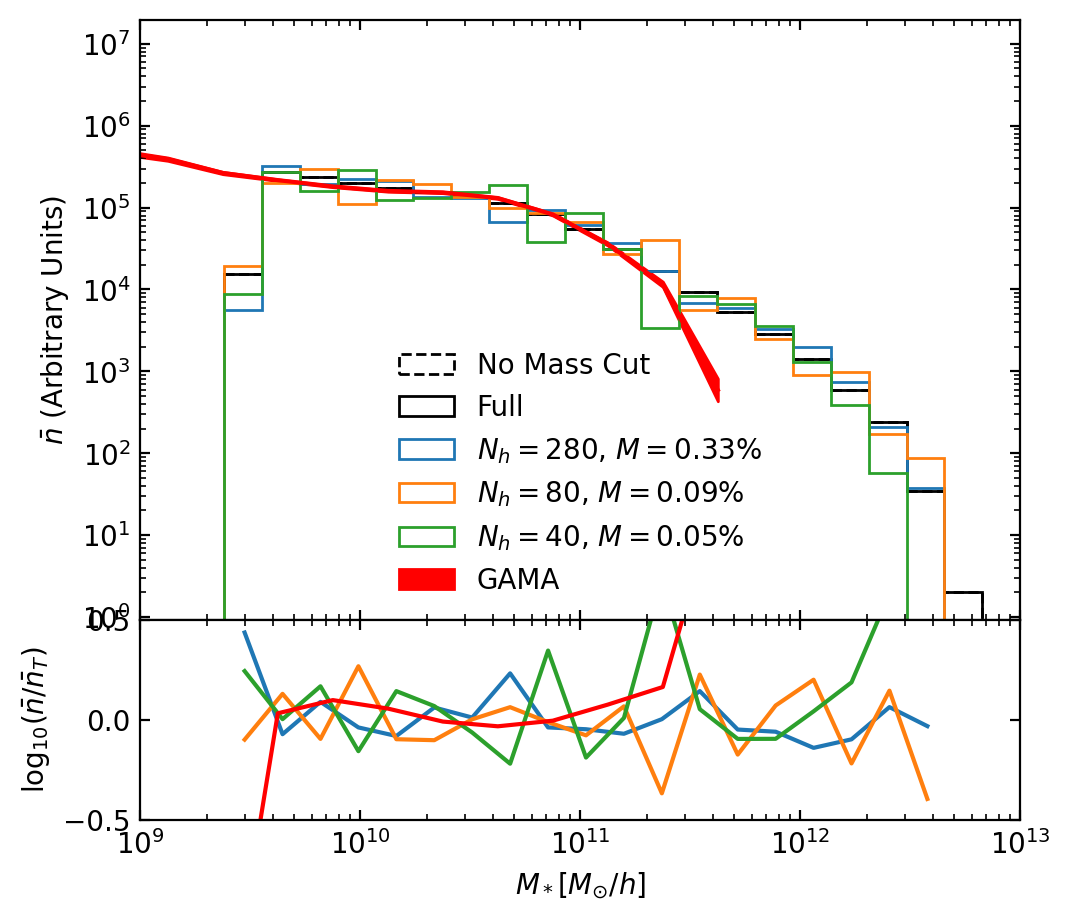

In [19]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

centers = 0.5*(dic[0]['total'][vmax_sel[0]]['smf'][1][:-1] + dic[0]['total'][vmax_sel[0]]['smf'][1][1:])
bins = dic[0]['total'][vmax_sel[0]]['smf'][1]

ax1.hist(0.5*(dic_full['smf'][1][1:]+dic_full['smf'][1][:-1]), bins=dic_full['smf'][1], weights=dic_full['smf'][0],\
         log=True, histtype='step', color='k', label='No Mass Cut', ls='--');

ax1.hist(centers, bins=bins, weights=smf_sum['total'],\
         log=True, histtype='step', color='k', label='Full');

for s in range(1, len(sels)):
    ax1.hist(centers, bins=bins, weights=smf_sum[sels[s]], log=True, histtype='step',\
                label='$N_h={:d}$, $M={:.2f}\%$'.format(n_sum[sels[s]], 100*m_sum[sels[s]]/M_tot/1e10), color='C{:d}'.format(s-1));

norm =3e7
ax1.plot(10**GAMA[:,0], norm*10**GAMA[:,1], color='r')
ax1.fill_between(10**GAMA[:,0], norm*10**(GAMA[:,1]-GAMA[:,2]), norm*10**(GAMA[:,1]+GAMA[:,2]), color='r', label='GAMA')

ax1.legend(loc='lower center')

ax1.set_xlim(1e9, 1e13)

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

# ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xscale('log')

for s in range(1, len(sels)):
    ax2.plot( centers, np.log10( smf_sum['total'] / smf_sum[sels[s]] ),  color='C{:d}'.format(s-1))

ax2.plot( 10**GAMA[:,0], np.log10( np.interp(10**GAMA[:,0], centers, smf_sum['total']) / (norm*10**GAMA[:,1]) ), color='r', label='GAMA')

ax2.set_xlim(1e9, 1e13)

ax2.set_ylim(-0.5,0.5)

#ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
#ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [ ]:
for m in range(mass_edges.shape[0]):
    fig = plt.figure(dpi=200, figsize=(5.5,5))

    ax1=fig.add_axes((.1,.3,.8,.6))

    ax1.set_xscale('log')

    lnsts = ['-', ':']
    for v in range(len(vmax_sel)):
        ax1.hist(0.5*(dic[m]['total'][vmax_sel[v]]['smf'][1][:-1] + dic[m]['total'][vmax_sel[v]]['smf'][1][1:]),\
                bins=dic[m]['total'][vmax_sel[v]]['smf'][1], weights=dic[m]['total'][vmax_sel[v]]['smf'][0]/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0]), log=True, histtype='step', color='k', label='Full',\
                ls=lnsts[v]);

        for s in range(1, len(sels)):
            ax1.hist(0.5*(dic[m][sels[s]][vmax_sel[v]]['smf'][1][:-1] + dic[m][sels[s]][vmax_sel[v]]['smf'][1][1:]),\
                    bins=dic[m][sels[s]][vmax_sel[v]]['smf'][1], weights=dic[m][sels[s]][vmax_sel[v]]['smf'][0]/np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0]), log=True, histtype='step',
                    label='$N_h={:d}$, ${:.2f}\%$'.format(dic[m][sels[s]][vmax_sel[v]]['Nh'], 100*np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0])/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0])),\
                    color='C{:d}'.format(s), ls=lnsts[v]);

    ax1.legend(loc='lower left', fontsize=6)

    ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

    ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

    ax2=fig.add_axes((.1,.1,.8,.2))        

    ax2.set_xscale('log')

    for v in range(len(vmax_sel)):
        for s in range(1, len(sels)):

            centers = 0.5*(dic[m][sels[s]][vmax_sel[v]]['smf'][1][:-1] + dic[m][sels[s]][vmax_sel[v]]['smf'][1][1:])

            ax2.plot( centers, (dic[m]['total'][vmax_sel[v]]['smf'][0]/np.sum(dic[m]['total'][vmax_sel[v]]['smf'][0])) / (dic[m][sels[s]][vmax_sel[v]]['smf'][0]/np.sum(dic[m][sels[s]][vmax_sel[v]]['smf'][0])) - 1, label='$N_h={:d}$'.format(nsels[s]), color='C{:d}'.format(s),\
                    ls=lnsts[v])

    ax2.set_ylim(-0.5,0.5)

    ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

    ax2.set_ylabel('Deviation')
    ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [182]:
sim.header['OmegaBaryon'] / sim.header['Omega']

0.15733247005503398

## What about gas-fraction

In [21]:
f_gas = {}
f_stel = {}
m500c = {}
for s in range(len(sels)):

    f_gas[sels[s]] = np.zeros(mass_edges.shape[0])
    f_stel[sels[s]] = np.zeros(mass_edges.shape[0])
    m500c[sels[s]] = np.zeros(mass_edges.shape[0])

    for m in range(mass_edges.shape[0]):
        f_gas[sels[s]][m] = np.mean( np.hstack( (sim.fof['halo_mfof_type'][:,0][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof_type'][:,0][dic[m][sels[s]]['high']['h_idx']]) )\
                                     / np.hstack( (sim.fof['halo_mfof'][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof'][dic[m][sels[s]]['high']['h_idx']]) ) )
        f_stel[sels[s]][m] = np.mean( np.hstack((sim.fof['halo_mfof_type'][:,4][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof_type'][:,4][dic[m][sels[s]]['high']['h_idx']]))\
                                     / np.hstack((sim.fof['halo_mfof'][dic[m][sels[s]]['low']['h_idx']], sim.fof['halo_mfof'][dic[m][sels[s]]['high']['h_idx']])) )
        m500c[sels[s]][m] = np.mean( np.hstack((sim.fof['halo_m500c'][dic[m][sels[s]]['low']['h_idx']]*1e10, sim.fof['halo_m500c'][dic[m][sels[s]]['high']['h_idx']]*1e10)) )


2024-02-20 15:52:38,993 bacco.sims : Reading 99870210 items for GroupMassType


2024-02-20 15:53:06,283 bacco.sims : Reading 99870210 items for Group_M_Crit500


### And the bias coevolution relations?

(10000000000000.0, 300000000000000.0)

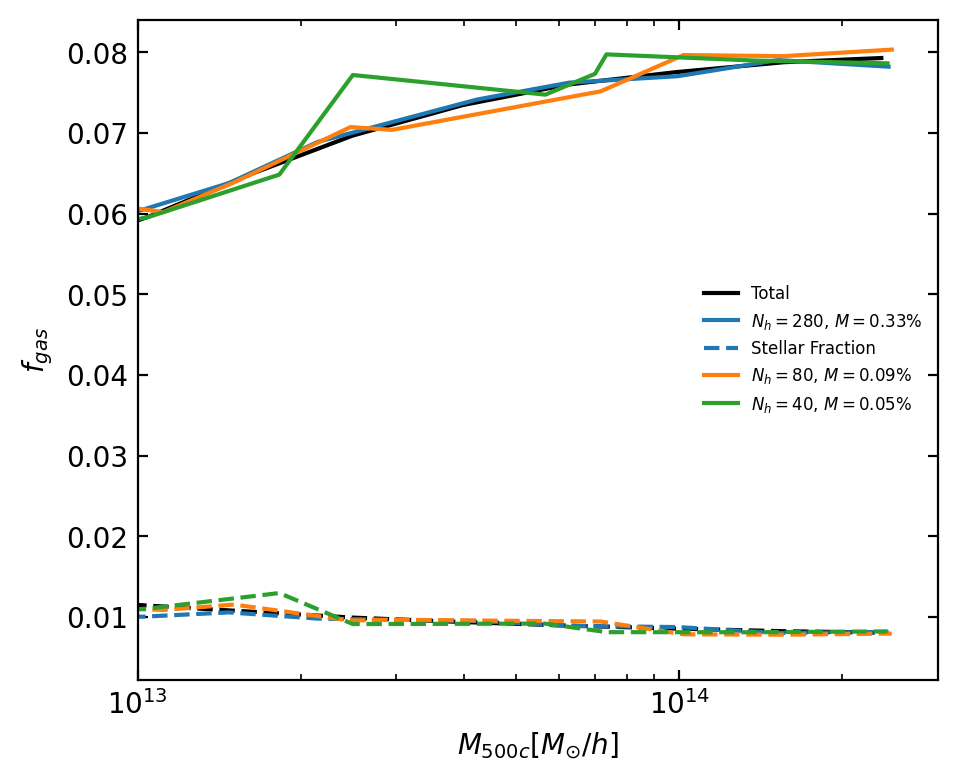

In [22]:
fig = plt.figure(dpi=200, figsize=(5,5.5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

ax1.plot(m500c['total'], f_gas['total'], color='k', label='Total')
ax1.plot(m500c['total'], f_stel['total'], color='k', ls='--')

for s in range(1, len(sels)):
    label='$N_h={:d}$, $M={:.2f}\%$'.format(n_sum[sels[s]], 100*m_sum[sels[s]]/M_tot/1e10)
    ax1.plot(m500c[sels[s]], f_gas[sels[s]], color='C{:d}'.format(s-1), label=label)
    if(s==1):
        ax1.plot(m500c[sels[s]], f_stel[sels[s]], color='C{:d}'.format(s-1), ls='--', label='Stellar Fraction')
    else:
        ax1.plot(m500c[sels[s]], f_stel[sels[s]], color='C{:d}'.format(s-1), ls='--')

ax1.legend(fontsize=6)

ax1.set_ylabel('$f_{gas}$')
ax1.set_xlabel('$M_{500c}[M_{\odot}/h]$')

ax1.set_xlim(1e13, 3e14)

# ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

# ax2=fig.add_axes((.1,.1,.8,.2))        

# ax2.set_xscale('log')

# ax2.set_ylabel('Deviation')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [419]:
smf_total = {}; smf = {}; mhalos = {}; Nhalos = {}
for m in range(mass_edges.shape[0]):
    mhalos[m] = {}
    Nhalos[m] = {}

    smf_total[m], mhalos[m]['total'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], nbins=Nbins)
    
    smf[m] = {}

    Nhalos[m]['10'] = max( min(400, int(0.1*nhalos[m]['total']) ), 15 )
    smf[m]['10'], mhalos[m]['10'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['10'], nbins=Nbins)
    Nhalos[m]['1'] = max( min(400, int(0.01*nhalos[m]['total']) ), 15 )
    smf[m]['1'], mhalos[m]['1'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['1'], nbins=Nbins)
    Nhalos[m]['0.5'] = max( min(400, int(0.005*nhalos[m]['total']) ), 15 )
    smf[m]['0.5'], mhalos[m]['0.5'], _ = stellar_mf(sim=sim, mass_edges=mass_edges[m], Nhalos=Nhalos[m]['0.5'], nbins=Nbins)


/tmp/ipykernel_34749/3062605995.py:35: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
/tmp/ipykernel_34749/3062605995.py:35: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
/tmp/ipykernel_34749/3062605995.py:36: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
/tmp/ipykernel_34749/3062605995.py:36: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
/tmp/ipykernel_34749/3062605995.py:37: RuntimeWarning: divide 

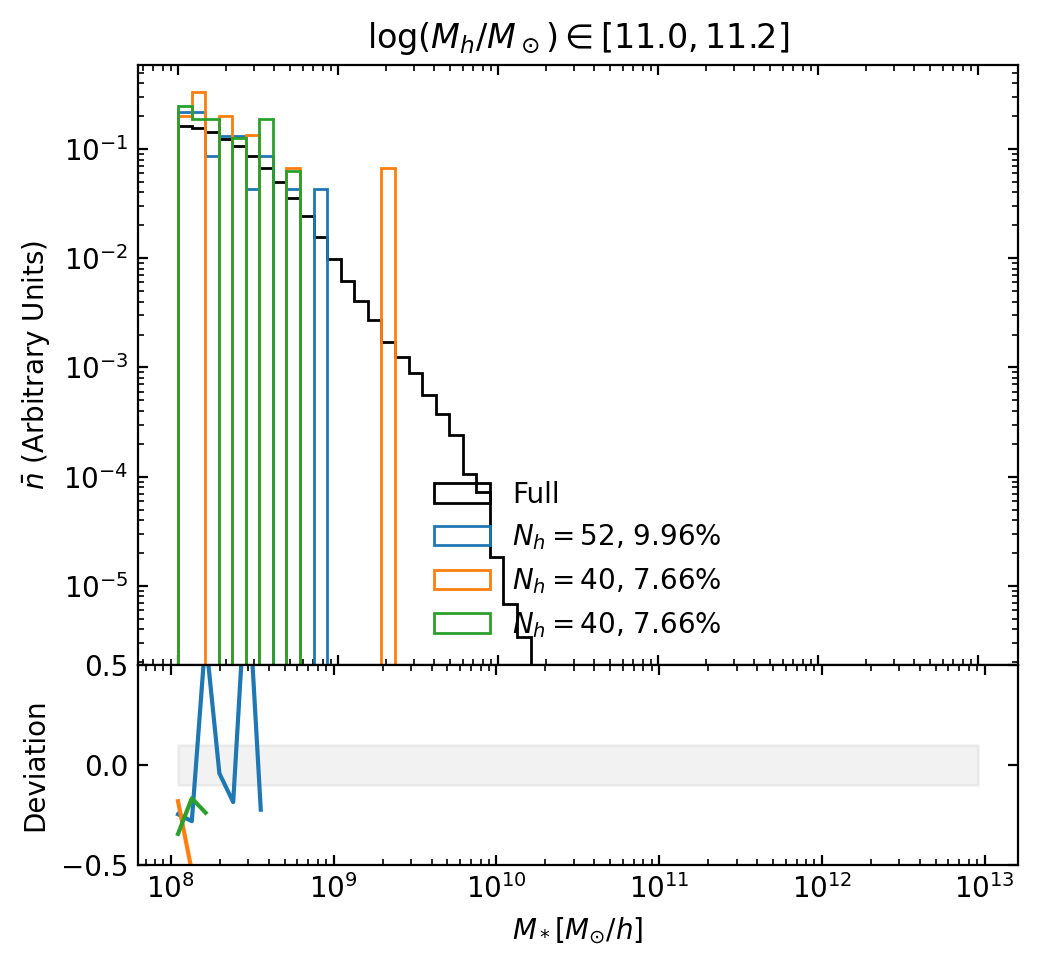

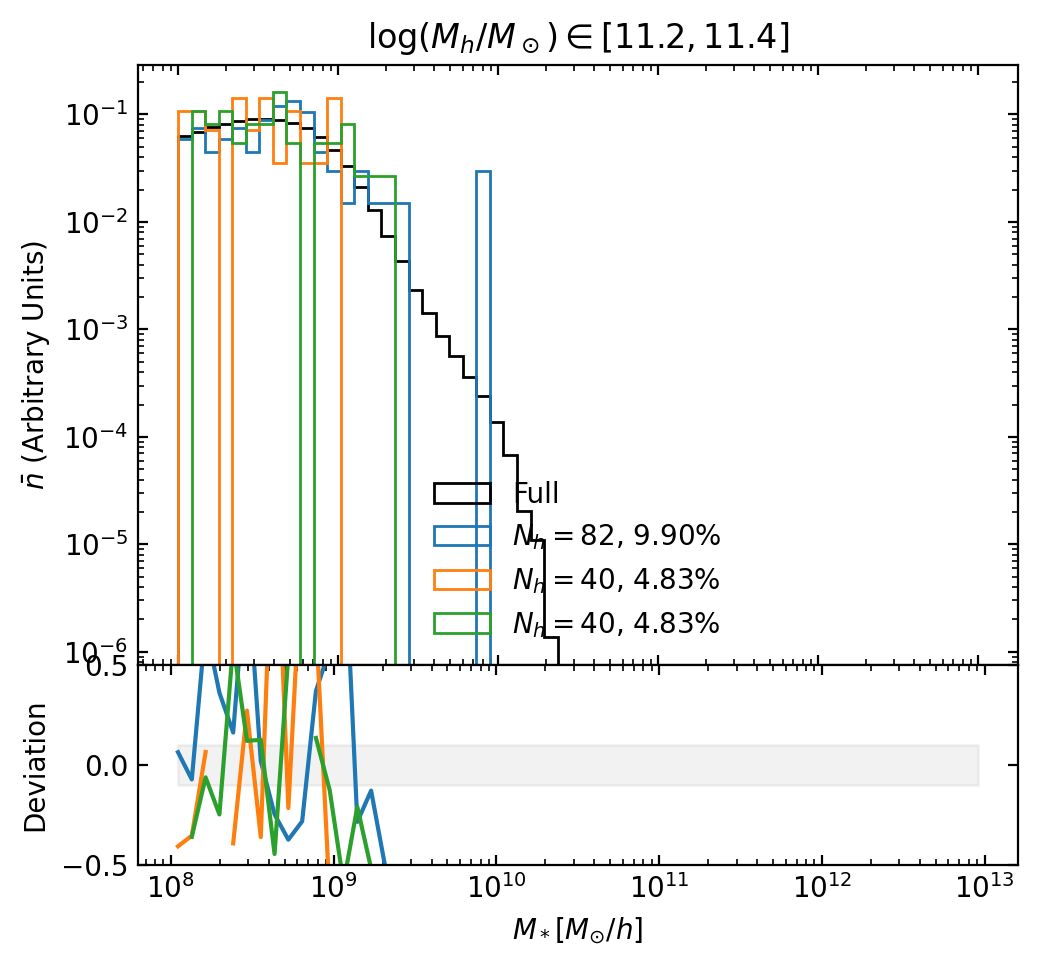

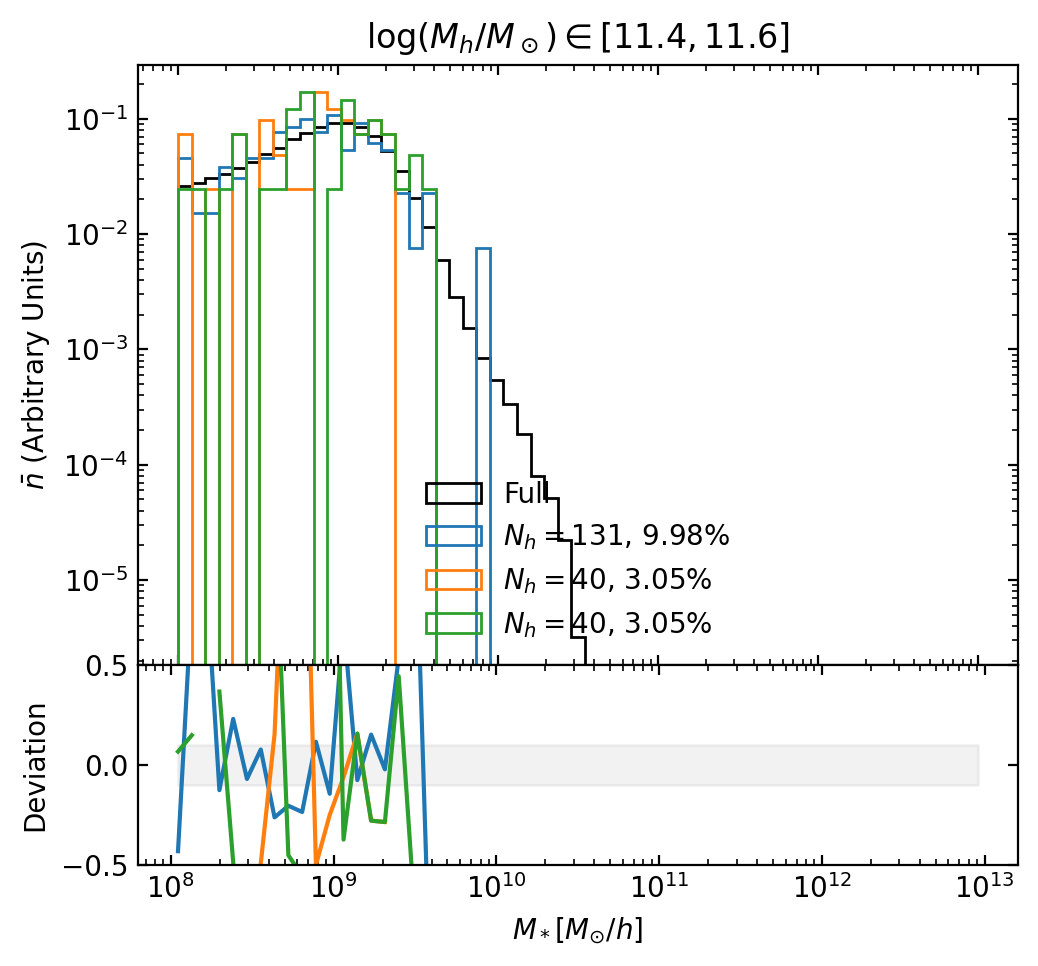

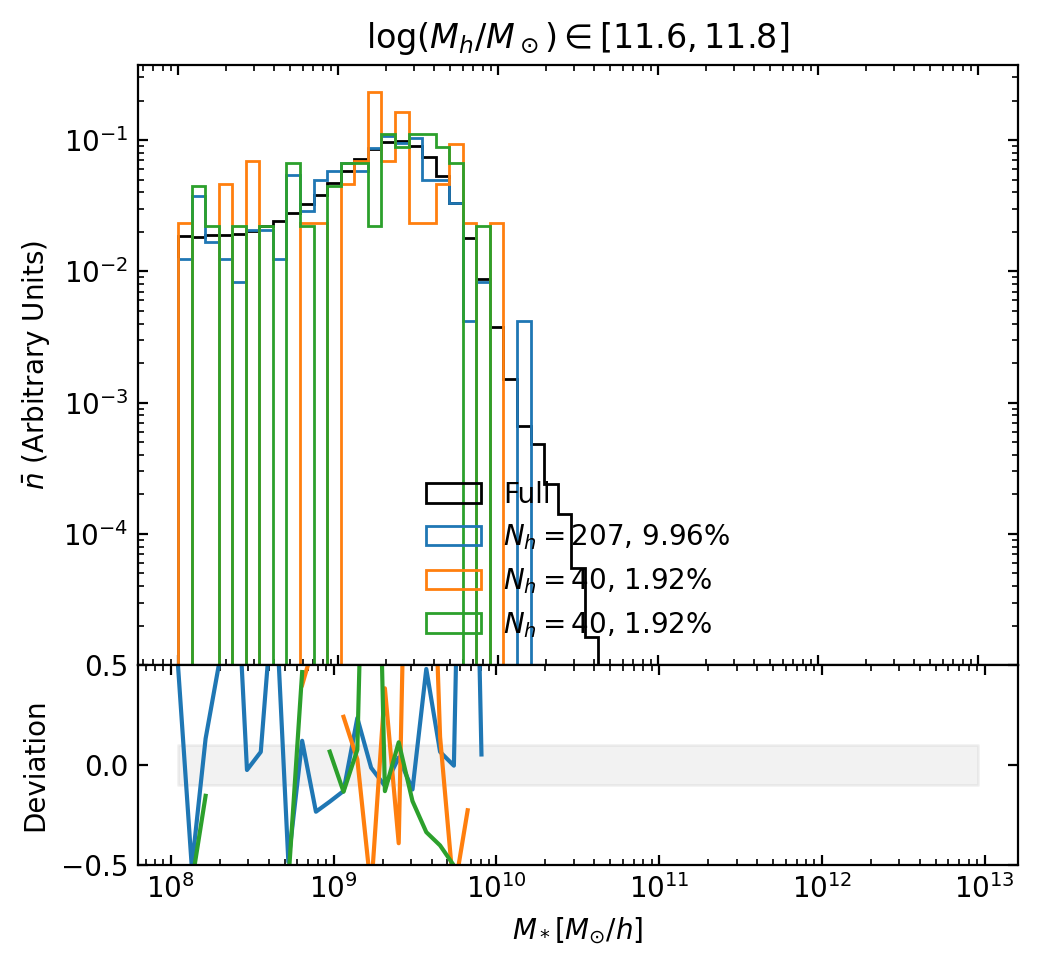

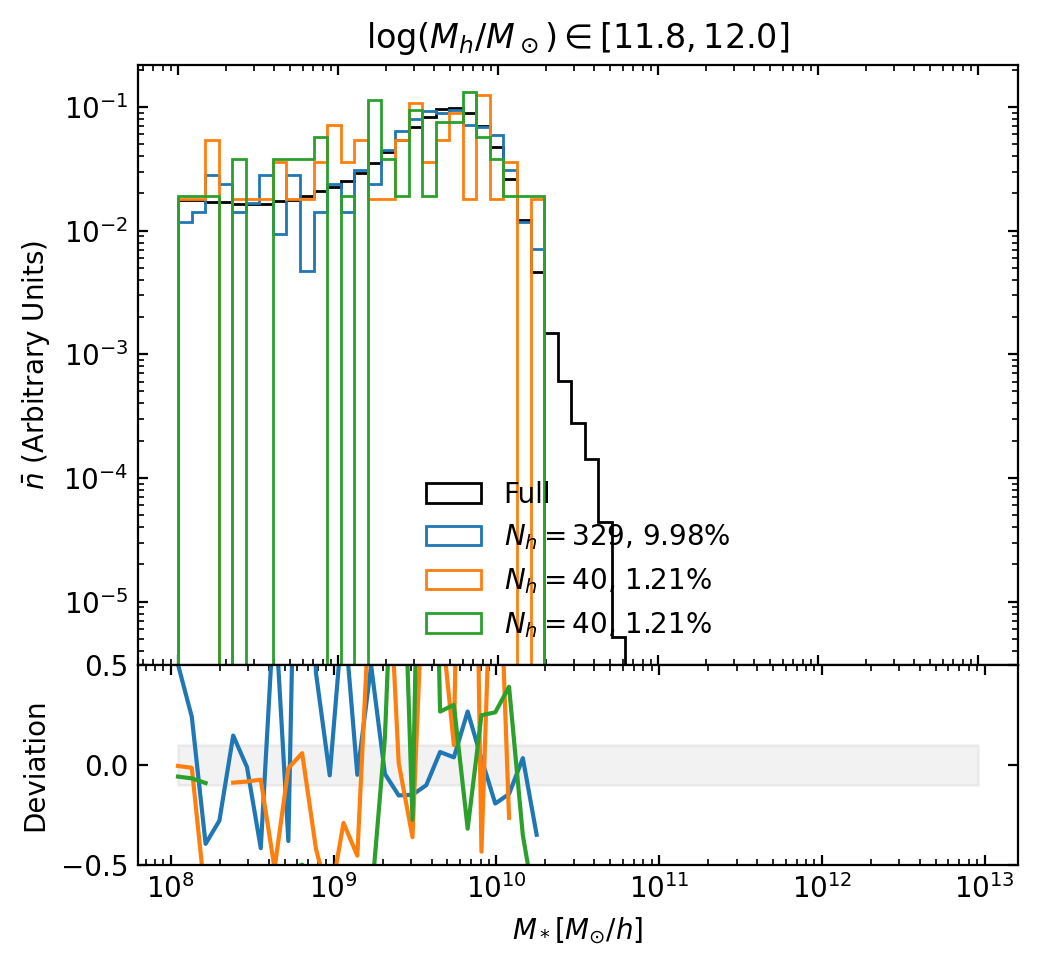

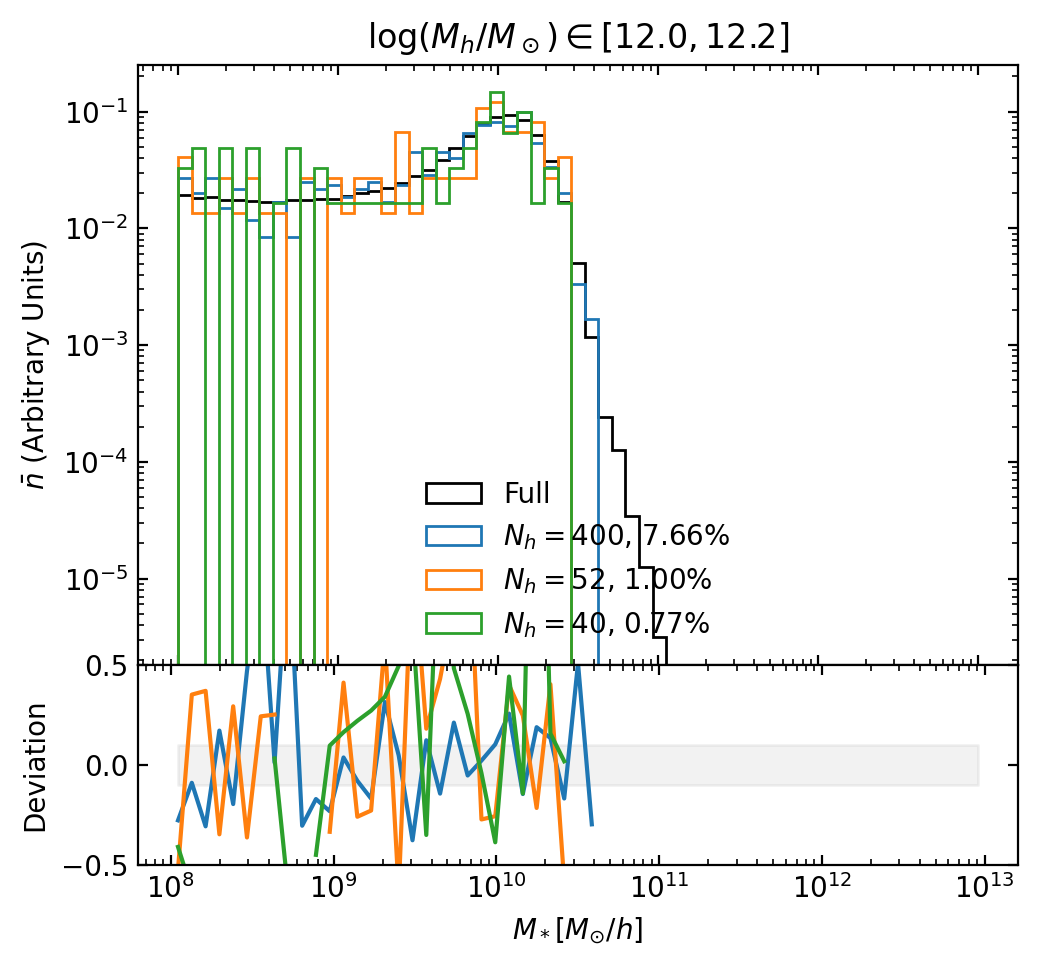

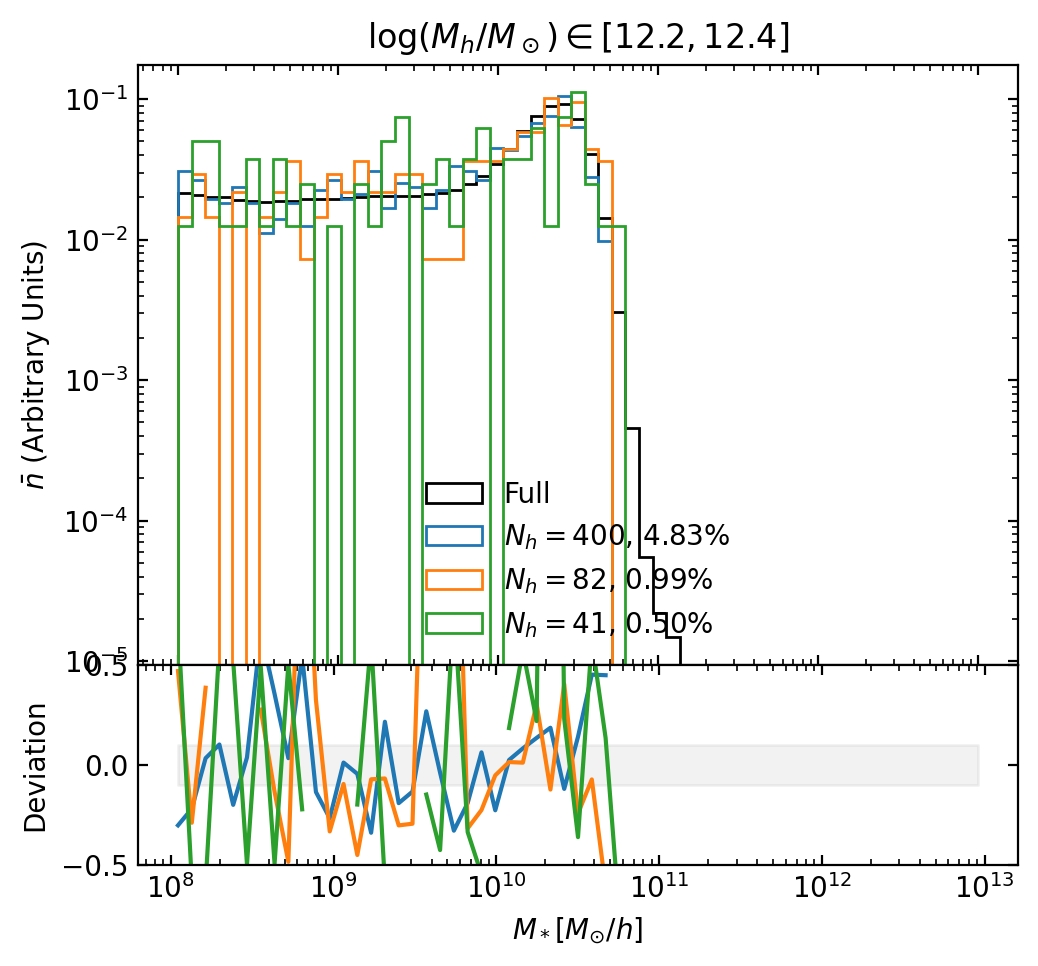

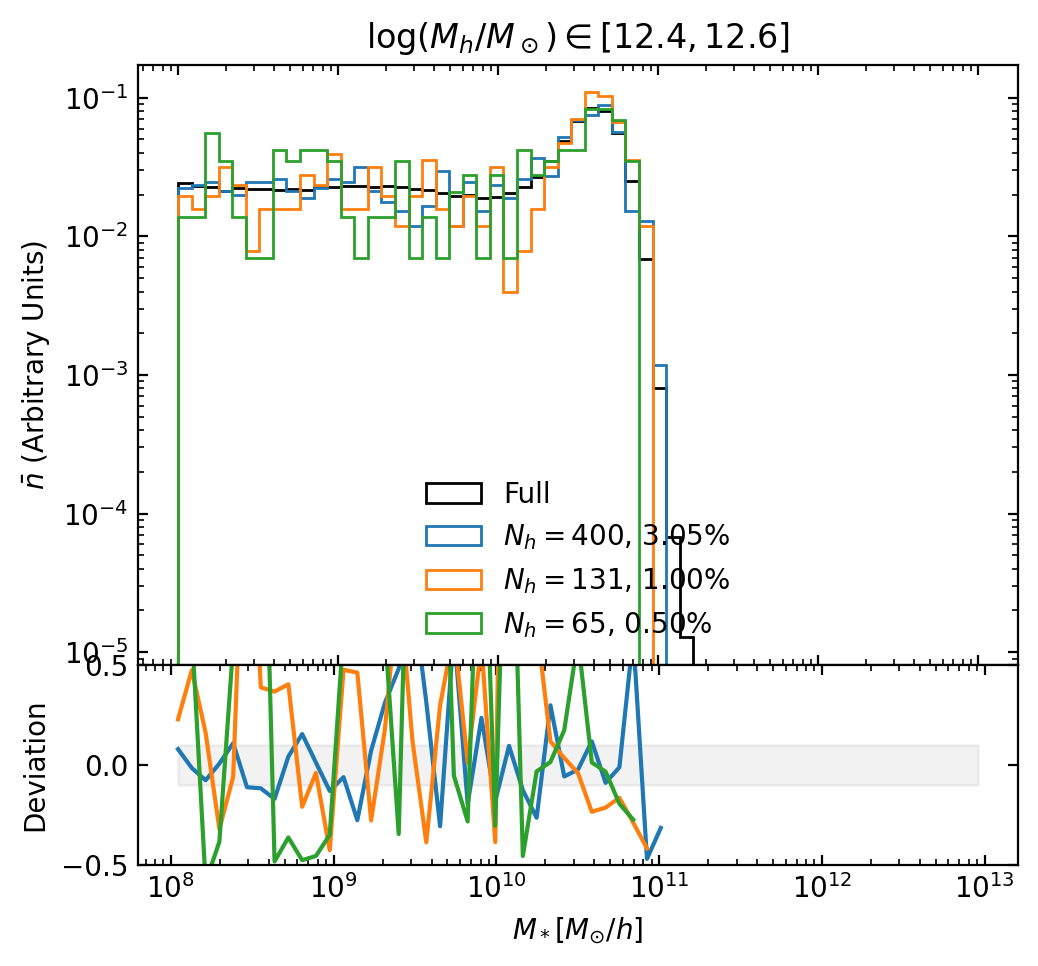

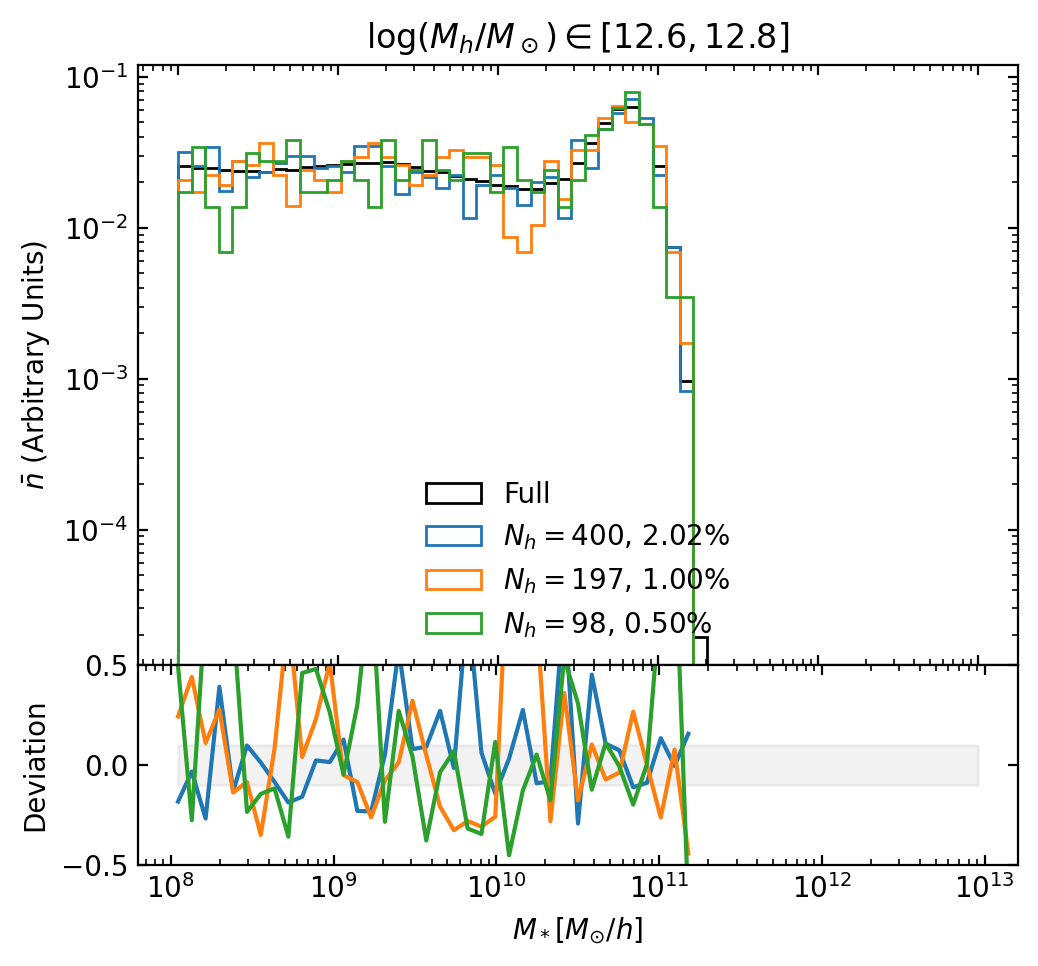

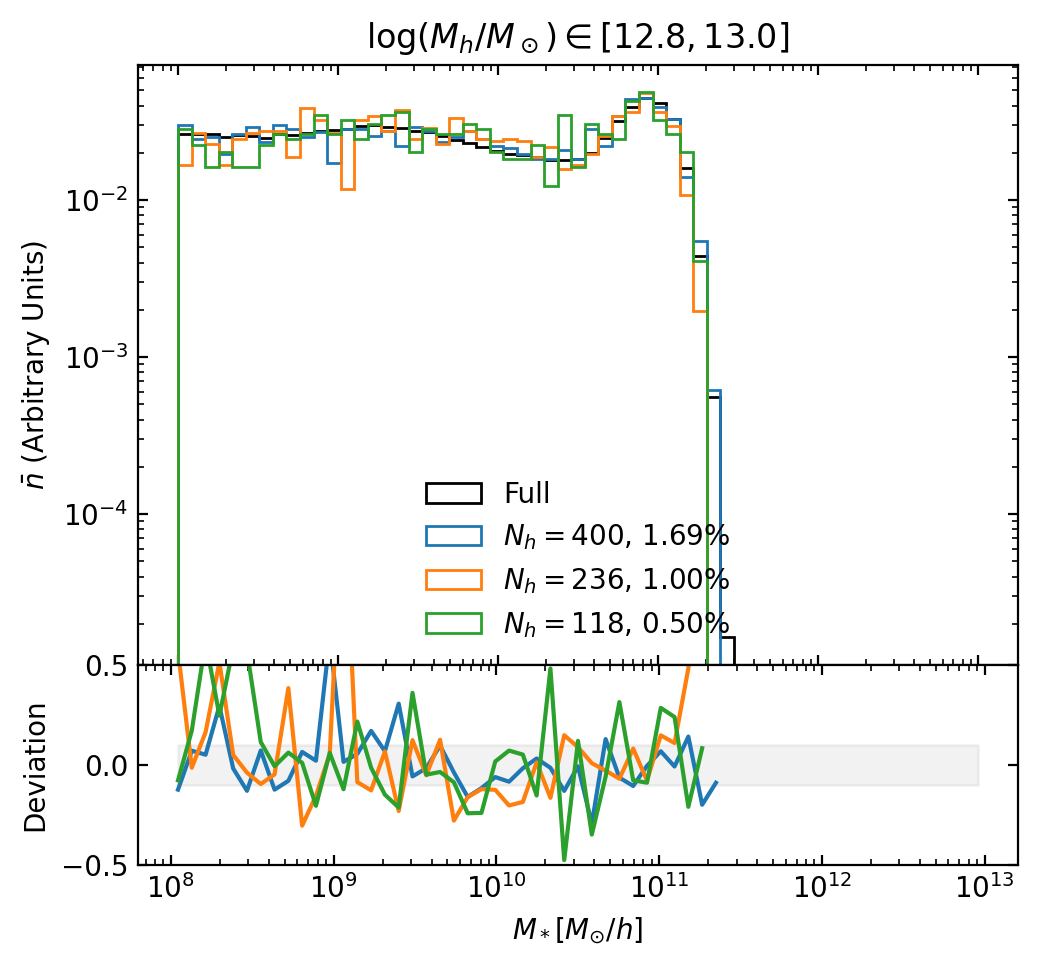

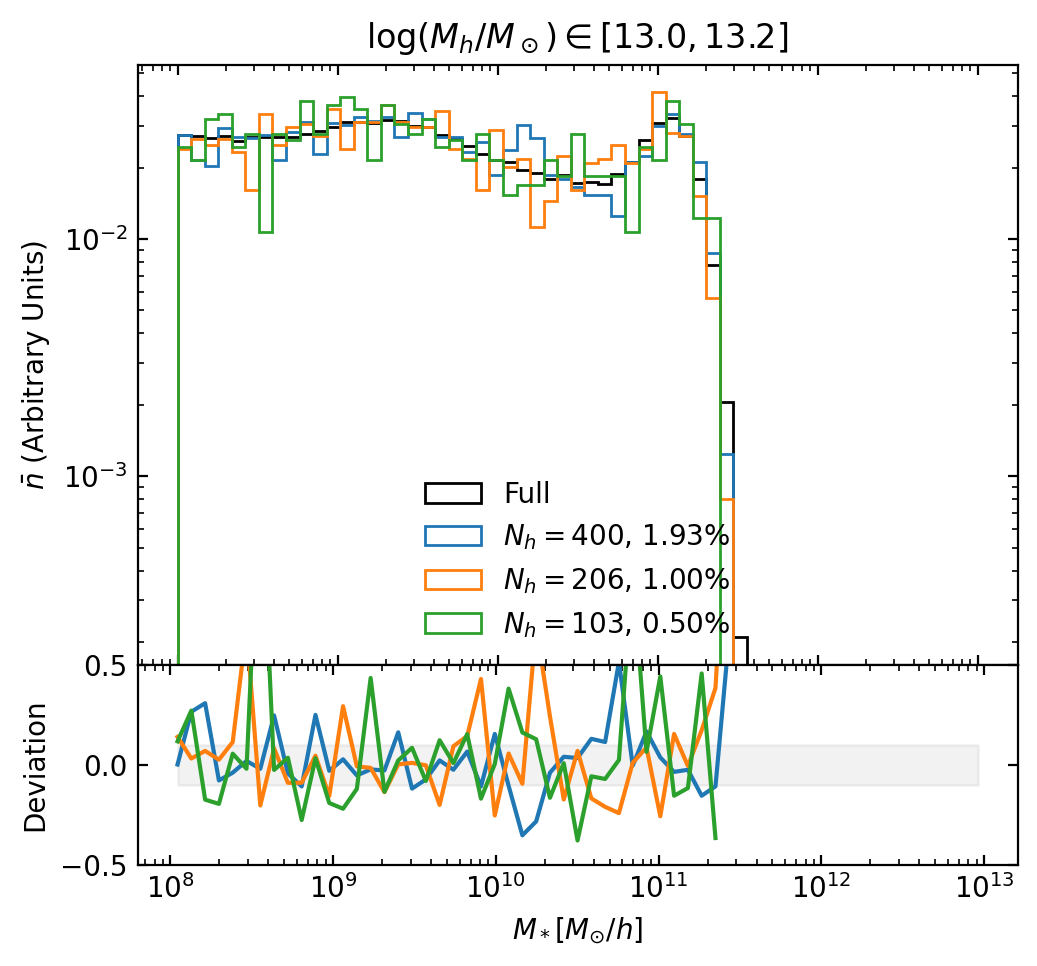

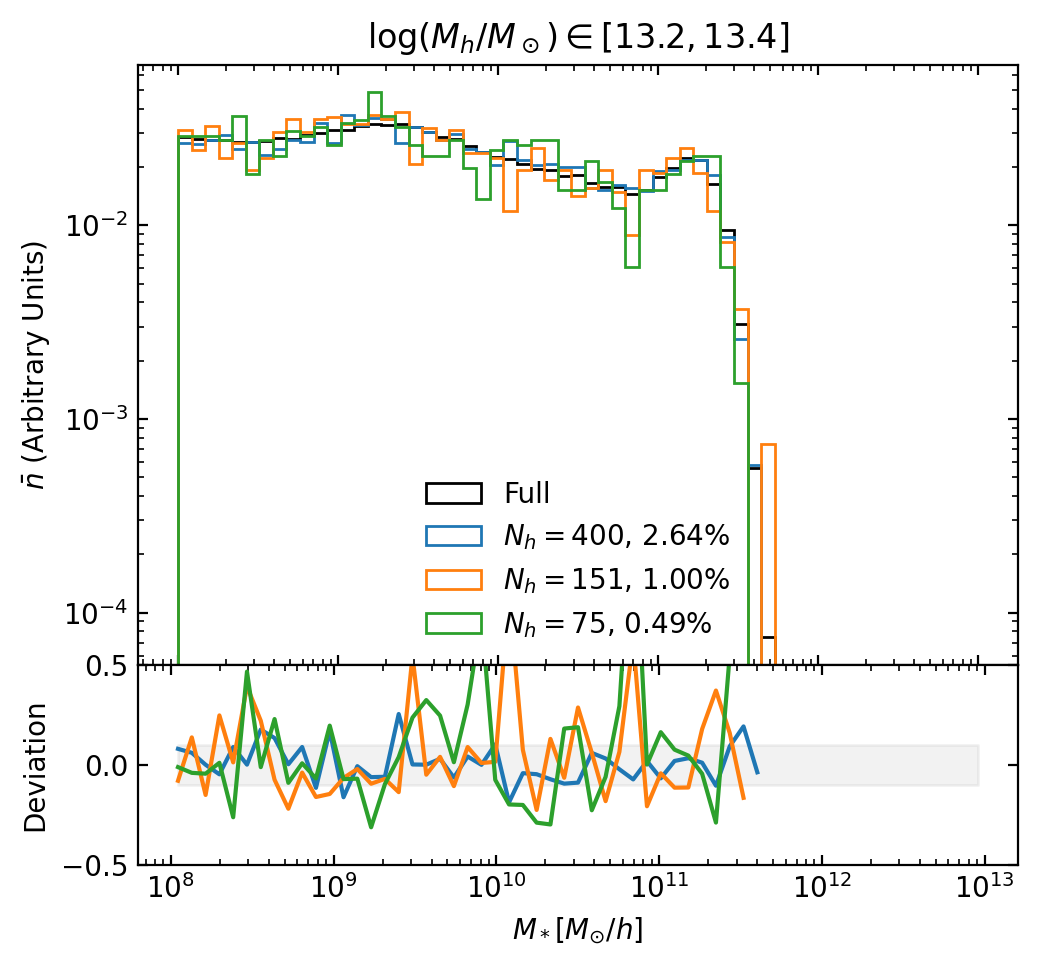

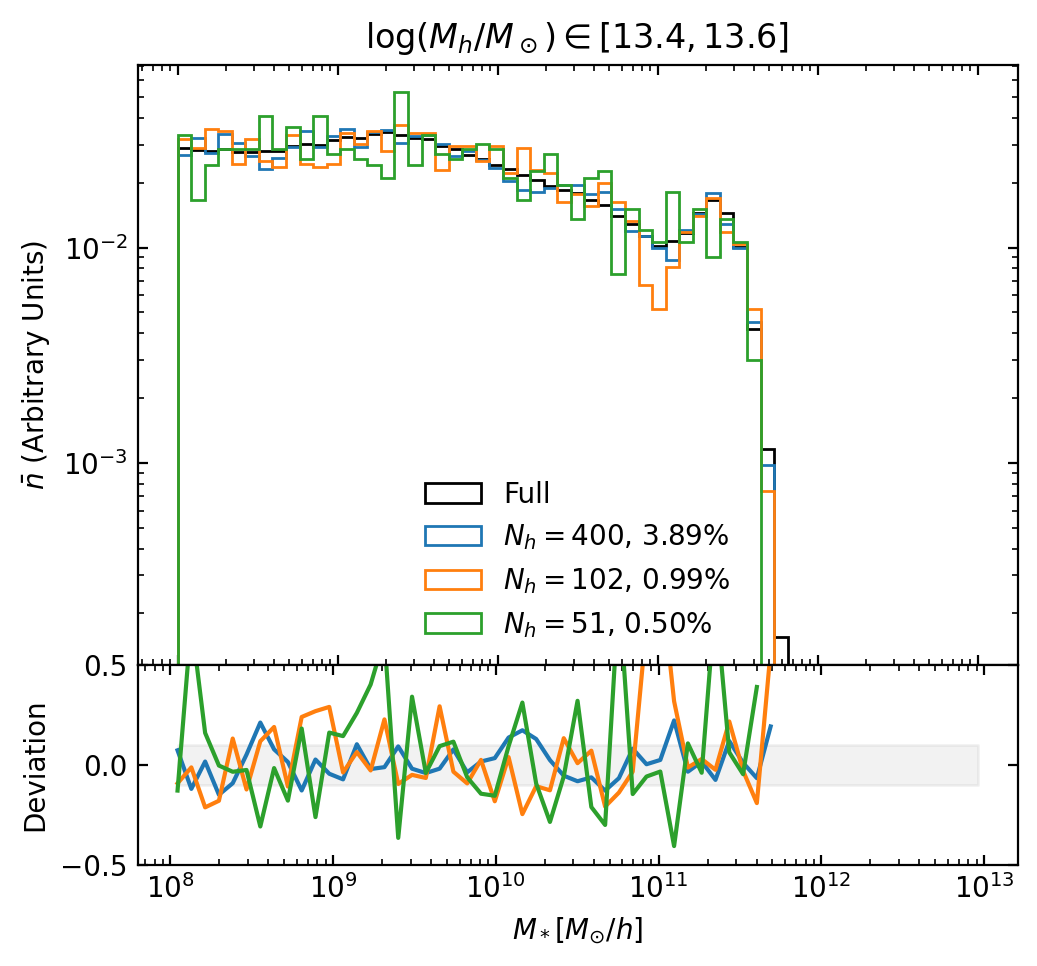

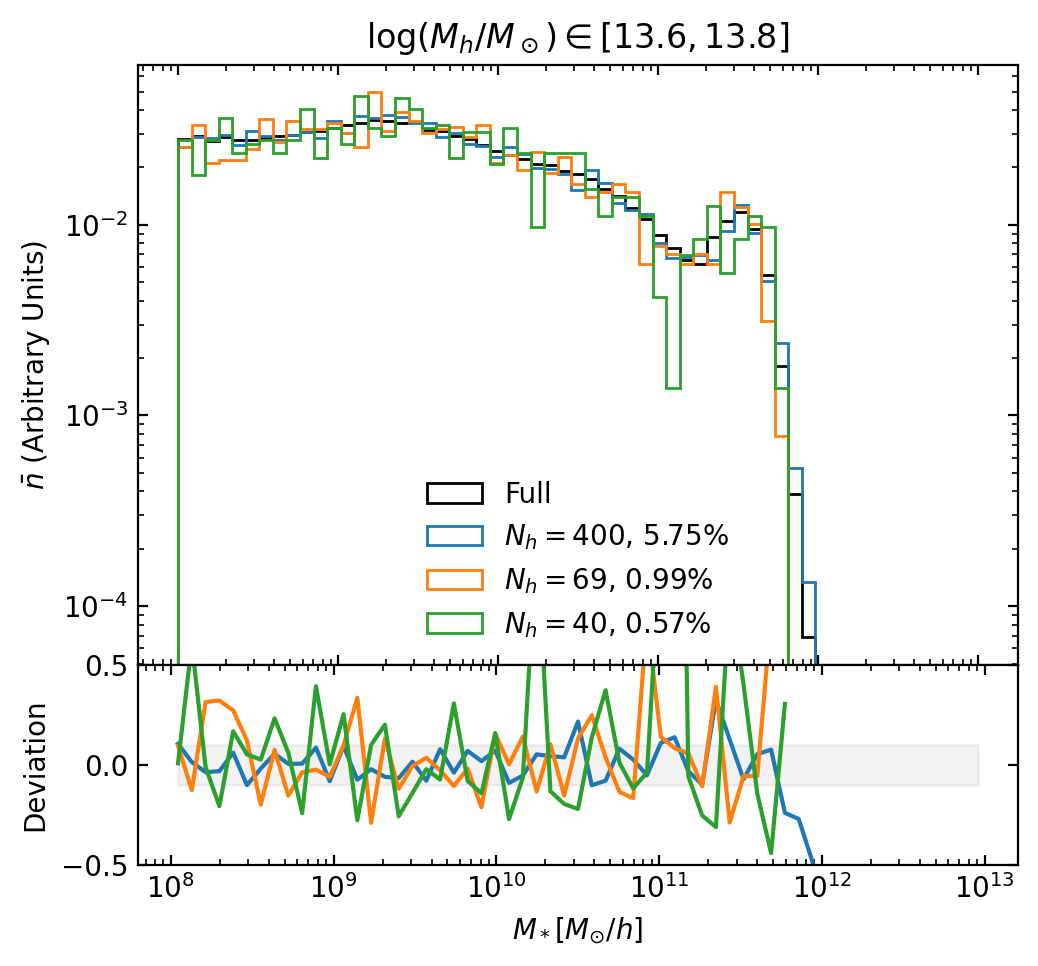

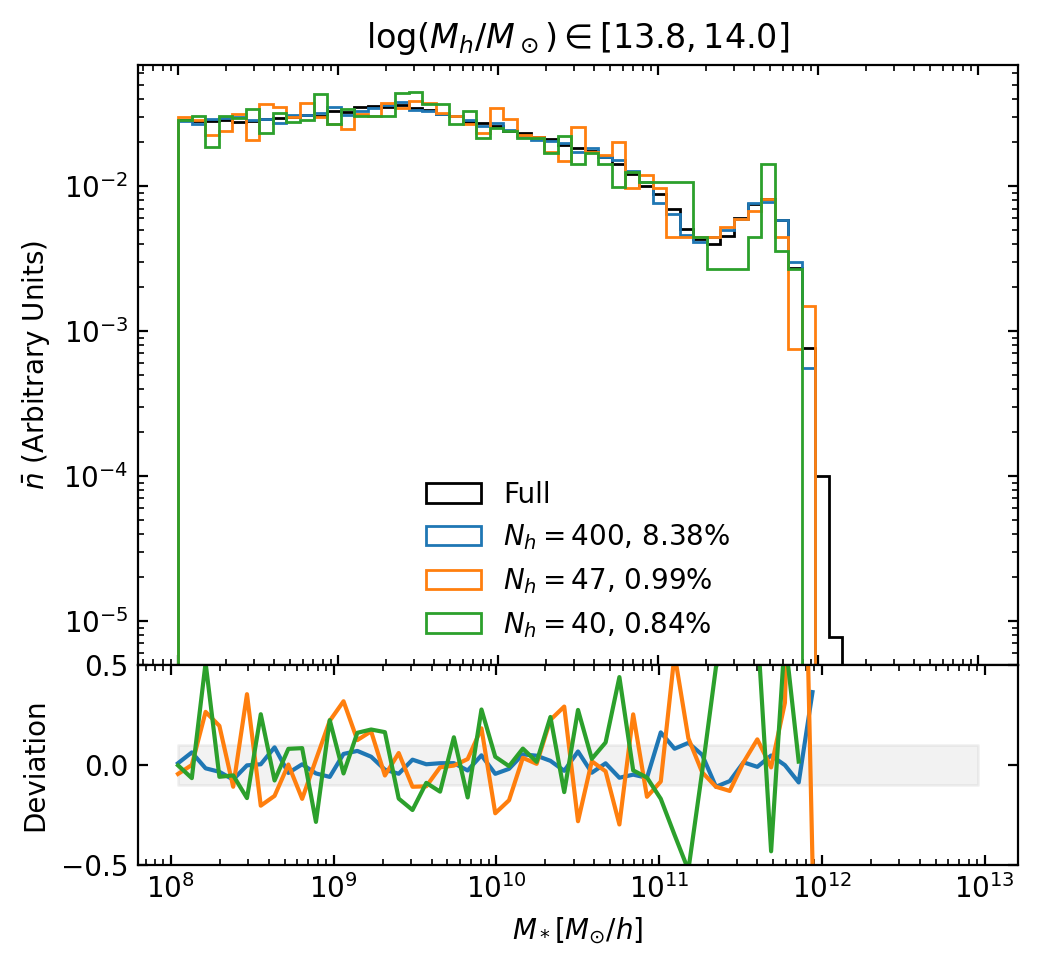

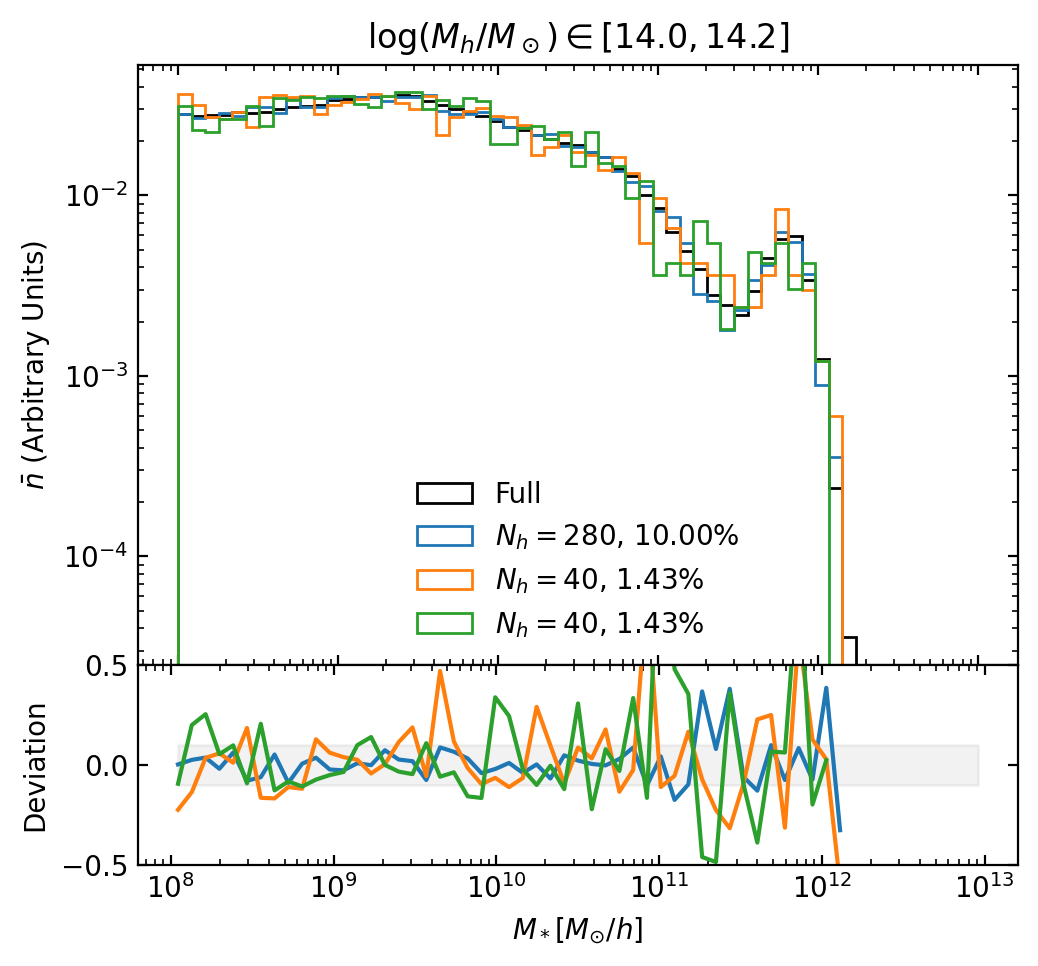

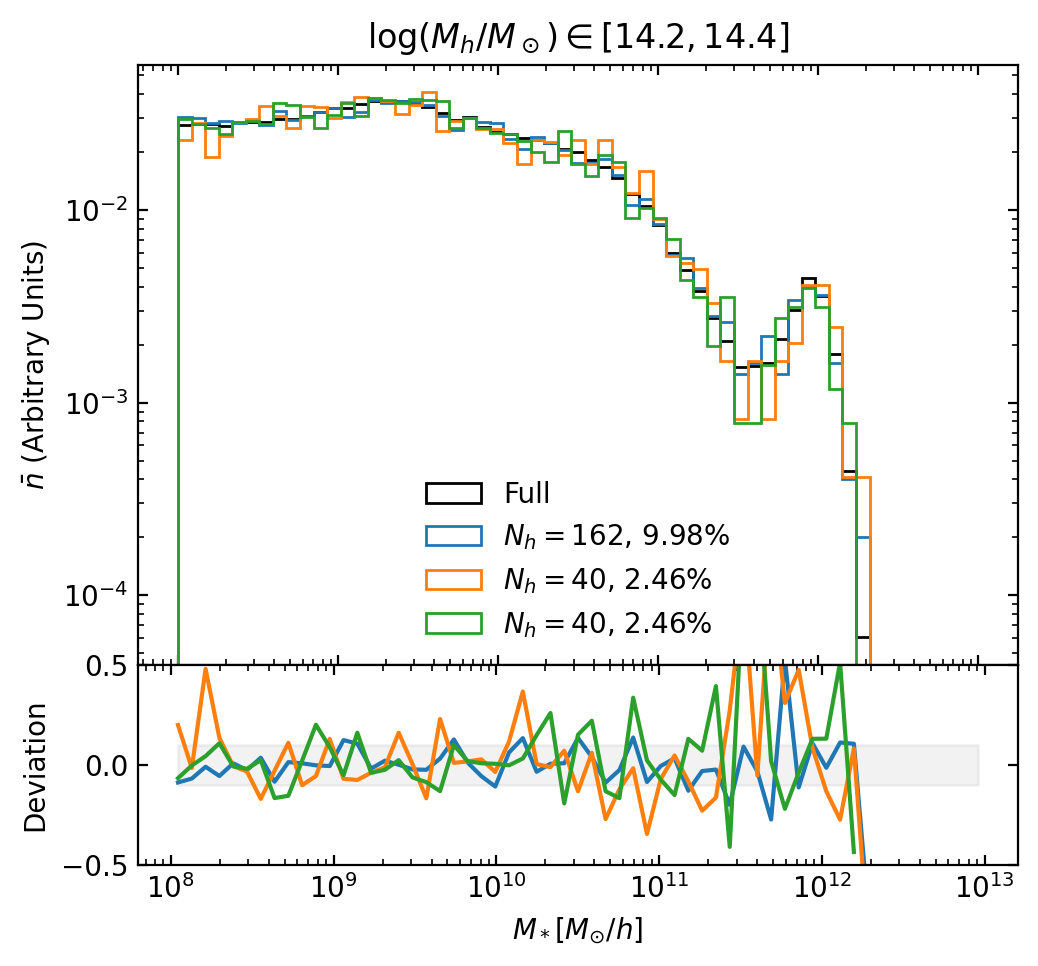

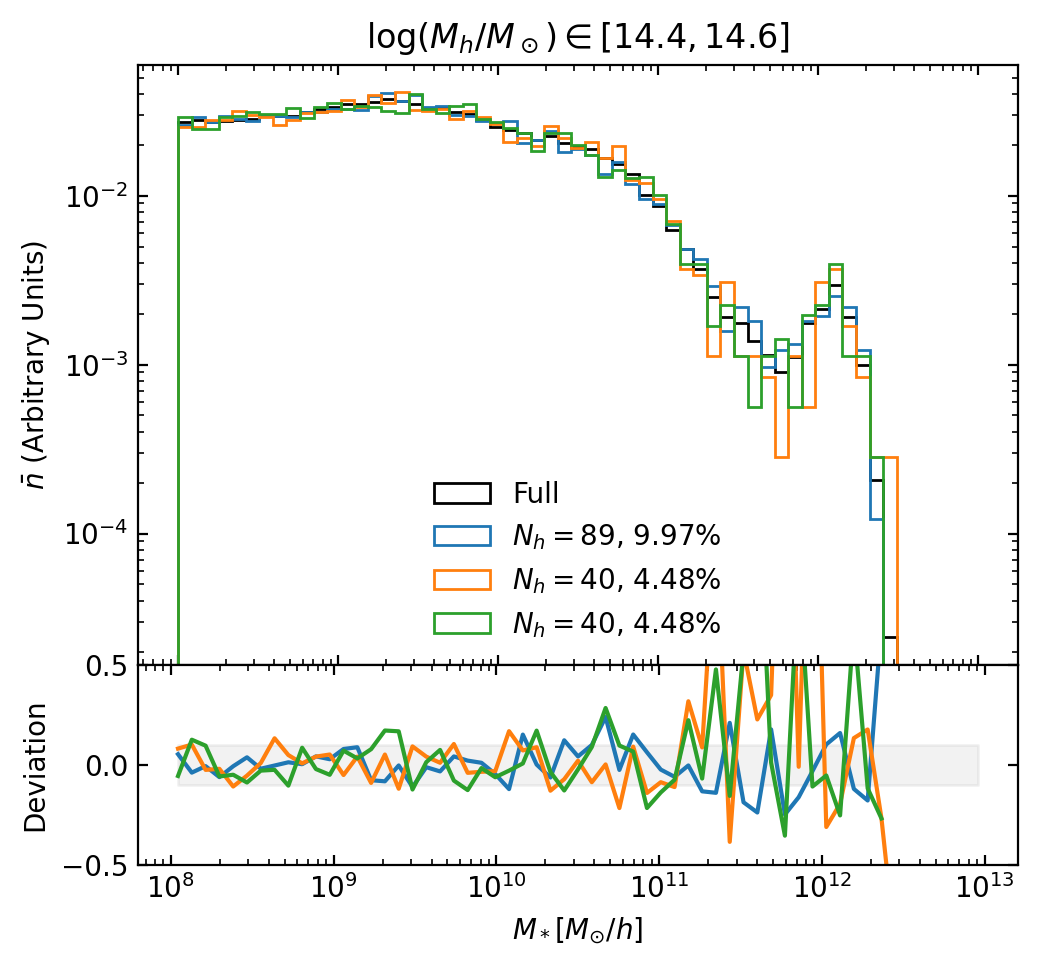

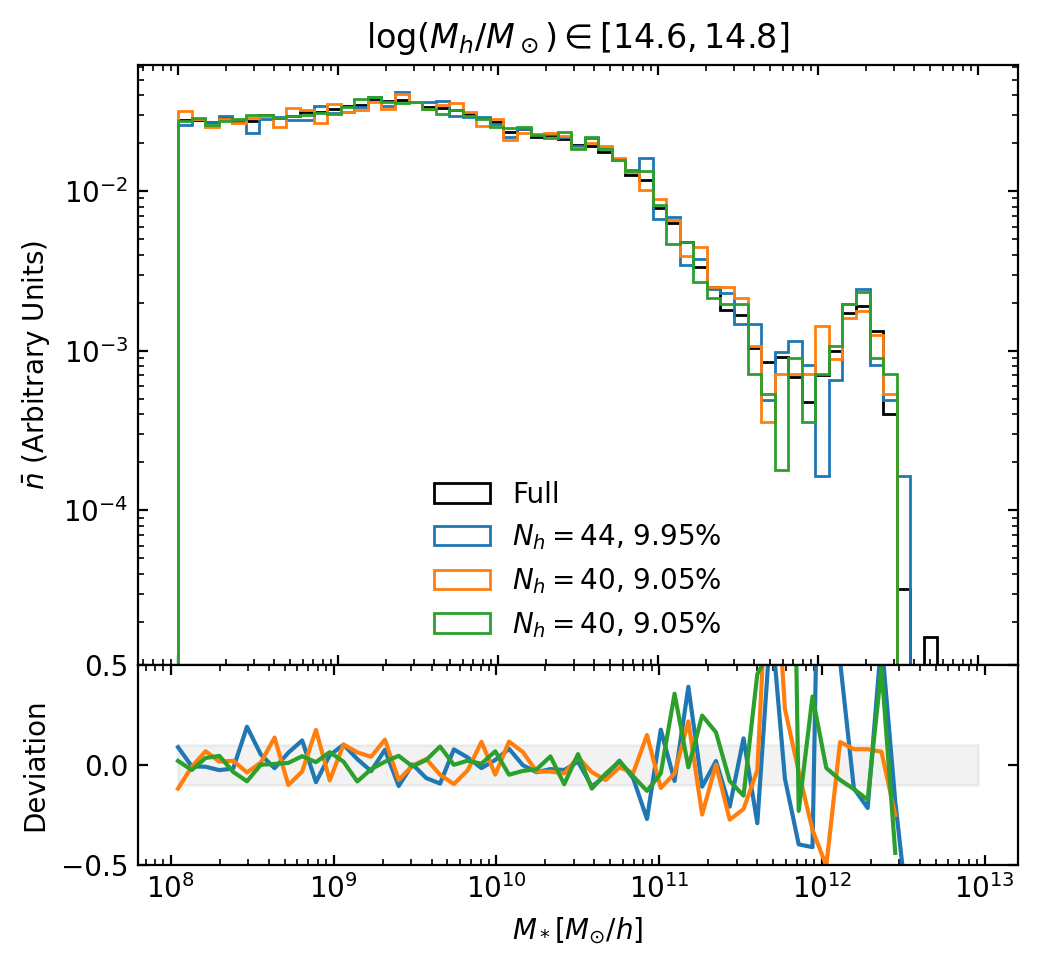

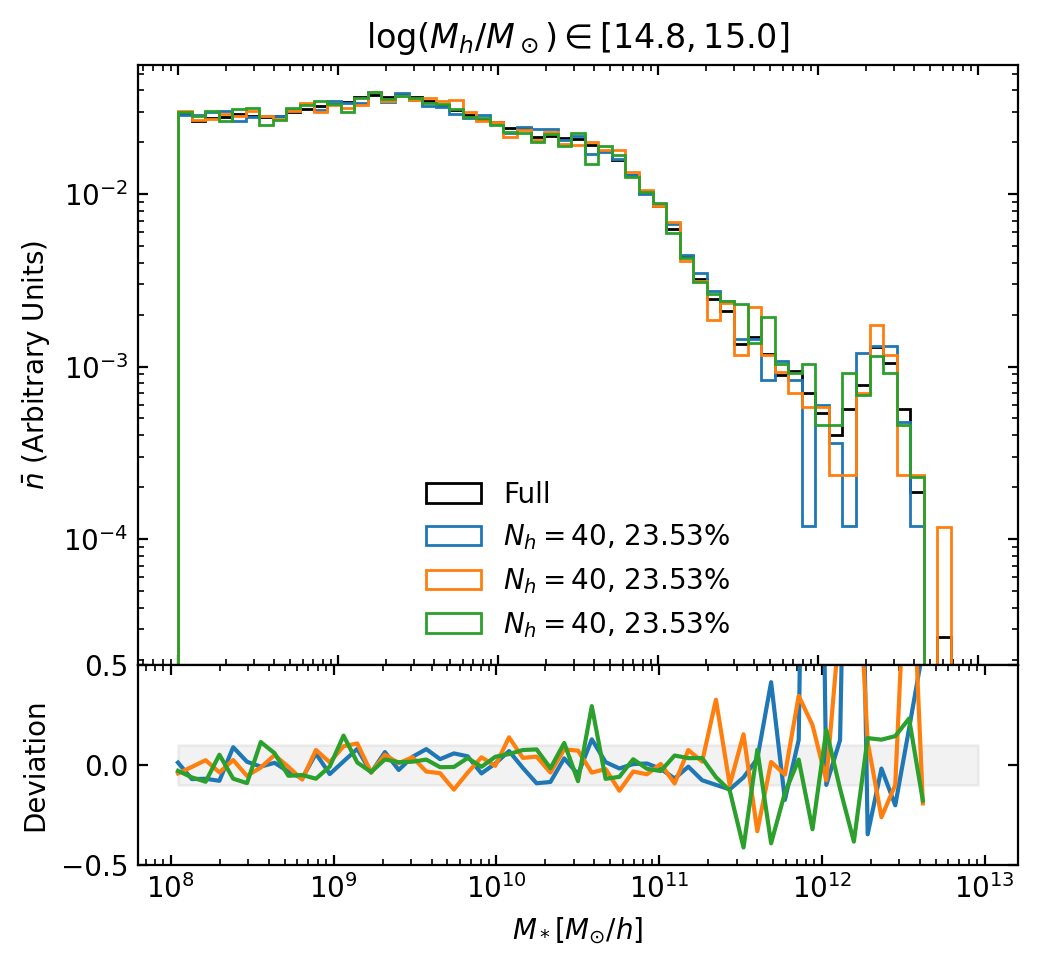

In [420]:
for m in range(mass_edges.shape[0]):
    fig = plt.figure(dpi=200, figsize=(5.5,5))

    ax1=fig.add_axes((.1,.3,.8,.6))

    ax1.set_xscale('log')

    ax1.hist(0.5*(smf_total[m][1][:-1] + smf_total[m][1][1:]),\
             bins=smf_total[m][1], weights=smf_total[m][0]/np.sum(smf_total[m][0]), log=True, histtype='step', color='k', label='Full');

    ax1.hist(0.5*(smf[m]['10'][1][:-1] + smf[m]['10'][1][1:]),\
             bins=smf[m]['10'][1], weights=smf[m]['10'][0]/np.sum(smf[m]['10'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['10'], 100*Nhalos[m]['10']/nhalos[m]['total']), color='C0');

    ax1.hist(0.5*(smf[m]['1'][1][:-1] + smf[m]['1'][1][1:]),\
             bins=smf[m]['1'][1], weights=smf[m]['1'][0]/np.sum(smf[m]['1'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['1'], 100*Nhalos[m]['1']/nhalos[m]['total']), color='C1');

    ax1.hist(0.5*(smf[m]['0.5'][1][:-1] + smf[m]['0.5'][1][1:]),\
             bins=smf[m]['0.5'][1], weights=smf[m]['0.5'][0]/np.sum(smf[m]['0.5'][0]), log=True, histtype='step',
             label='$N_h={:d}$, ${:.2f}\%$'.format(Nhalos[m]['0.5'], 100*Nhalos[m]['0.5']/nhalos[m]['total']), color='C2');

    ax1.legend(loc='lower center')

    ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

    ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

    ax2=fig.add_axes((.1,.1,.8,.2))        

    ax2.set_xscale('log')

    centers = 0.5*(smf[m]['0.5'][1][:-1] + smf[m]['0.5'][1][1:])

    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['10'][0]/np.sum(smf[m]['10'][0])) - 1, label='$N_h=10^4$', color='C0')
    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['1'][0]/np.sum(smf[m]['1'][0])) - 1, label='$N_h=10^3$', color='C1')
    ax2.plot( centers, (smf_total[m][0]/np.sum(smf_total[m][0])) / (smf[m]['0.5'][0]/np.sum(smf[m]['0.5'][0])) - 1, label='$N_h=200$', color='C2')

    ax2.set_ylim(-0.5,0.5)

    ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

    ax2.set_ylabel('Deviation')
    ax2.set_xlabel('$M_*[M_{\odot}/h]$')

In [450]:
smf_total_sum = np.zeros(len(smf_total[0][0]))
smf_sum = {}
smf_sum['10'] = np.zeros(len(smf_total[0][0]))
smf_sum['1'] = np.zeros(len(smf_total[0][0]))
smf_sum['0.5'] = np.zeros(len(smf_total[0][0]))


m_sum ={}
m_sum['total'] = 0
m_sum['10'] = 0
m_sum['1'] = 0
m_sum['0.5'] = 0
for m in range(12):
    
    smf_total_sum += smf_total[m][0]
    smf_sum['10'] += smf[m]['10'][0] / (np.sum(smf[m]['10'][0])/np.sum(smf_total[m][0]))
    smf_sum['1'] += smf[m]['1'][0] / (np.sum(smf[m]['1'][0])/np.sum(smf_total[m][0]))
    smf_sum['0.5'] += smf[m]['0.5'][0] / (np.sum(smf[m]['0.5'][0])/np.sum(smf_total[m][0]))

    m_sum['total'] += np.sum(mhalos[m]['total'])
    m_sum['10'] += np.sum(mhalos[m]['10'])
    m_sum['1'] += np.sum(mhalos[m]['1'])
    m_sum['0.5'] += np.sum(mhalos[m]['0.5'])

/tmp/ipykernel_34749/2803807174.py:35: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
/tmp/ipykernel_34749/2803807174.py:35: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
/tmp/ipykernel_34749/2803807174.py:36: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
/tmp/ipykernel_34749/2803807174.py:36: RuntimeWarning: invalid value encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
/tmp/ipykernel_34749/2803807174.py:37: RuntimeWarning: divide by zero encountered in divide
  ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['0.5']/n

Text(0.5, 0, '$M_*[M_{\\odot}/h]$')

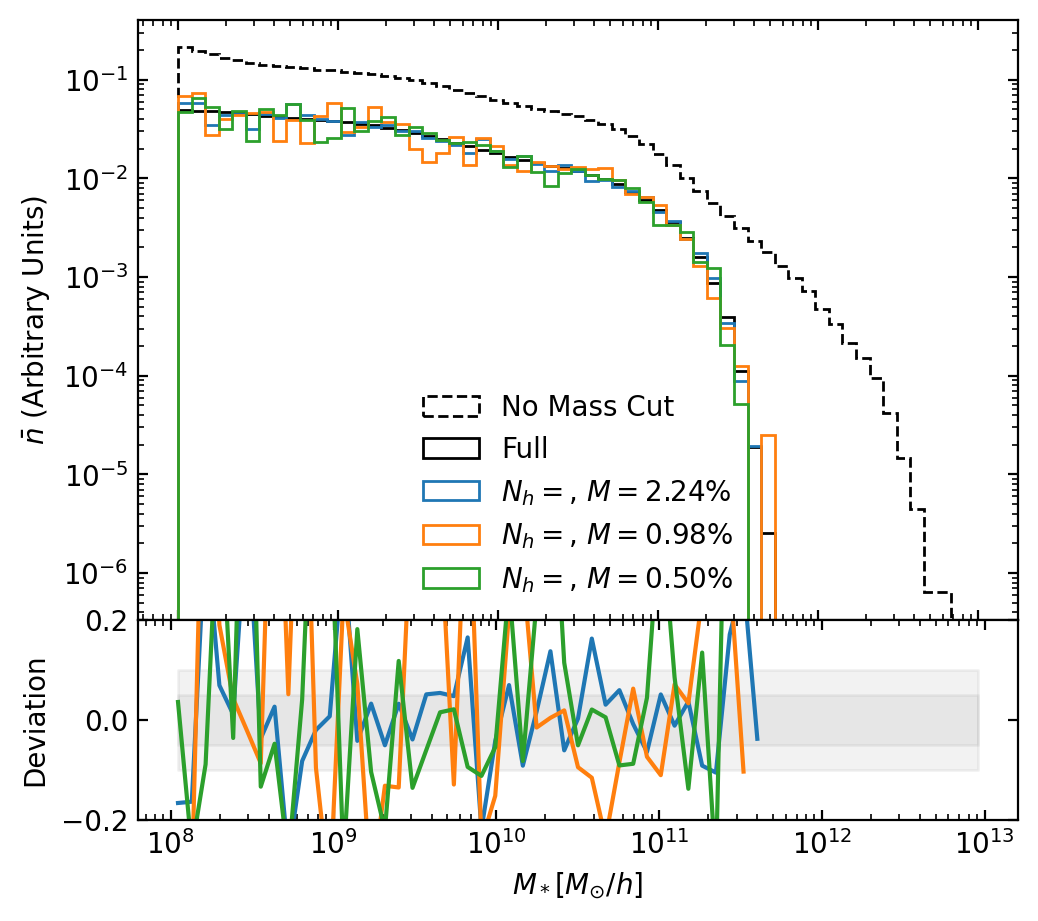

In [451]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')

centers = 0.5*(smf_total[0][1][:-1] + smf_total[0][1][1:])
bins = smf_total[0][1]

ax1.hist(centers, bins=bins, weights=3.5*smf_full[0]/np.sum(smf_full[0]),\
         log=True, histtype='step', color='k', label='No Mass Cut', ls='--');

ax1.hist(centers, bins=bins, weights=smf_total_sum/np.sum(smf_total_sum),\
         log=True, histtype='step', color='k', label='Full');

ax1.hist(centers, bins=bins, weights=smf_sum['10']/np.sum(smf_sum['10']), log=True, histtype='step',\
            label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['10']/m_sum['total']), color='C0');

ax1.hist(centers, bins=bins, weights=smf_sum['1']/np.sum(smf_sum['1']), log=True, histtype='step',\
         label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['1']/m_sum['total']), color='C1');

ax1.hist(centers, bins=bins, weights=smf_sum['0.5']/np.sum(smf_sum['0.5']), log=True, histtype='step',\
         label='$N_h=$, $M={:.2f}\%$'.format(100*m_sum['0.5']/m_sum['total']), color='C2');

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')

# ax1.set_title('$\log(M_h/M_\odot) \in [{:.1f},{:.1f}]$'.format(mass_edges[m][0], mass_edges[m][1]))

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xscale('log')

ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['10']/np.sum(smf_sum['10'])) - 1,  color='C0')
ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['1']/np.sum(smf_sum['1'])) - 1,  color='C1')
ax2.plot( centers, (smf_total_sum/np.sum(smf_total_sum)) / (smf_sum['0.5']/np.sum(smf_sum['0.5'])) - 1, color='C2')

ax2.set_ylim(-0.2,0.2)

ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

ax2.set_ylabel('Deviation')
ax2.set_xlabel('$M_*[M_{\odot}/h]$')